<a href="https://colab.research.google.com/github/NiharikaChavan/ObjectDetection/blob/main/Texture_Synthesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel

controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny")
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

# Create a control image that preserves surface structure
def prepare_control_image(image):
    # Edge detection preserves structural details
    canny = cv2.Canny(image, 100, 200)
    # Or use normal map for better structure preservation
    normals = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
    return normals

control_image = prepare_control_image(tabletop_region)

texture = pipe(
    prompt="premium oak wood grain texture, photorealistic, detailed surface structure, studio lighting",
    image=Image.fromarray(control_image),
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

KeyboardInterrupt: 

In [4]:
%pwd

'/content'

In [7]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2
import torch
import numpy as np
from PIL import Image

# Load the ControlNet model
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny",torch_dtype = torch.float16)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

# Create a control image that preserves surface structure
def prepare_control_image(image_path):
    # Load the segmented image
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Could not load image from path: {image_path}. Check if the path is correct and the image file is valid.")

    # Edge detection preserves structural details
    canny = cv2.Canny(image, 100, 200)

    # Convert to RGB for the diffusion model
    normals = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
    return normals, image

# Path to your segmented image
segmented_image_path = "/Table.jpg"  # REPLACE WITH YOUR PATH

# Process the segmented image
control_image, original_segmented_image = prepare_control_image(segmented_image_path)

# Save the control image for inspection (optional)
cv2.imwrite("/control_image.png", control_image)

# Generate the texture
texture = pipe(
    prompt="premium oak wood grain texture, photorealistic, detailed surface structure, studio lighting",
    image=Image.fromarray(control_image),
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

# Save the generated texture
texture.save("/generated_texture.png")

# Optional: Apply the texture back to the segmented region
def apply_texture(original_image, texture, mask_path=None):
    # If you have a separate mask file
    if mask_path:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    else:
        # Create mask from non-black pixels in the original segmented image
        gray = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)

    # Convert PIL Image to numpy array
    texture_np = np.array(texture)
    texture_np = cv2.cvtColor(texture_np, cv2.COLOR_RGB2BGR)  # PIL is RGB, OpenCV is BGR

    # Resize texture to match original image
    texture_np = cv2.resize(texture_np, (original_image.shape[1], original_image.shape[0]))

    # Create result image
    result = original_image.copy()

    # Apply texture using mask
    result = np.where(mask[:,:,np.newaxis] > 0, texture_np, result)

    return result

# If you want to apply the texture back (optional)
# mask_path = "path/to/your/tabletop_mask.png"  # If you have a separate mask
# result_image = apply_texture(original_segmented_image, texture, mask_path)
# cv2.imwrite("result_with_texture.png", result_image)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2
import torch
import numpy as np
from PIL import Image

# ... (rest of your code)

def prepare_control_image(image_path):
    # Load the segmented image
    image = cv2.imread(image_path)

    # Check if image loading was successful
    if image is None:
        raise ValueError(f"Could not load image from path: {image_path}. Check if the path is correct and the image file is valid.")

    # Edge detection preserves structural details
    canny = cv2.Canny(image, 100, 200)

    # Check if any edges were detected
    if canny.size == 0:
        raise ValueError("No edges were detected in the image. Try adjusting the Canny edge detection thresholds.")

    # Convert to RGB for the diffusion model
    normals = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
    return normals, image
# ... (rest of your code)

In [10]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def apply_textures_to_segments(segmentation_image_path):
    """
    Generate and apply textures directly from a segmentation image.
    No need for the original image since segmentation is already done.
    """
    # Load models
    controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16
    ).to("cuda")

    # Load segmentation image
    segmentation_image = cv2.imread('/Table.jpg')
    if segmentation_image is None:
        raise ValueError(f"Could not load segmentation image from {segmentation_image_path}")

    # Convert to HSV for color-based segmentation
    hsv = cv2.cvtColor(segmentation_image, cv2.COLOR_BGR2HSV)

    # Define segments with their colors and desired textures
    segments = [
        {
            "name": "tabletop",
            "color": {"lower": np.array([20, 100, 100]), "upper": np.array([40, 255, 255])},  # Yellow/gold color
            "prompt": "premium oak wood grain texture, photorealistic, detailed surface structure, tabletop"
        },
        {
            "name": "tablelegs",
            "color": {
                "lower1": np.array([0, 100, 100]), "upper1": np.array([10, 255, 255]),      # Red lower range
                "lower2": np.array([160, 100, 100]), "upper2": np.array([180, 255, 255])    # Red upper range
            },
            "prompt": "polished dark walnut wood texture, table legs, photorealistic, smooth finish"
        }
    ]

    # Create a blank canvas for the final result (RGB)
    height, width = segmentation_image.shape[:2]
    result_image = np.zeros((height, width, 3), dtype=np.uint8)

    # Process each segment
    for segment in segments:
        print(f"Processing segment: {segment['name']}")

        # Create mask based on color
        if "lower1" in segment["color"]:  # For colors that wrap around HSV space (like red)
            mask1 = cv2.inRange(hsv, segment["color"]["lower1"], segment["color"]["upper1"])
            mask2 = cv2.inRange(hsv, segment["color"]["lower2"], segment["color"]["upper2"])
            mask = cv2.bitwise_or(mask1, mask2)
        else:
            mask = cv2.inRange(hsv, segment["color"]["lower"], segment["color"]["upper"])

        # Clean up mask with morphological operations
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Skip if no pixels in this segment
        if cv2.countNonZero(mask) == 0:
            print(f"No pixels found for segment: {segment['name']}")
            continue

        # Create a basic structure/shape image for the controlnet
        # We'll create a simple edge detection from the mask
        structure_image = np.zeros((height, width), dtype=np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(structure_image, contours, -1, 255, 2)

        # Add some internal structure if it's a large segment
        if cv2.countNonZero(mask) > 10000:  # Arbitrary threshold
            # Add some random lines or patterns inside for more interesting texture structure
            for i in range(10):
                pt1 = (np.random.randint(0, width), np.random.randint(0, height))
                pt2 = (np.random.randint(0, width), np.random.randint(0, height))
                if mask[pt1[1], pt1[0]] > 0 and mask[pt2[1], pt2[0]] > 0:
                    cv2.line(structure_image, pt1, pt2, 255, 1)

        # Convert to RGB for ControlNet
        structure_rgb = cv2.cvtColor(structure_image, cv2.COLOR_GRAY2RGB)

        # Generate texture using ControlNet
        texture = pipe(
            prompt=segment["prompt"],
            image=Image.fromarray(structure_rgb),
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]

        # Convert to numpy array and resize to match original size
        texture_np = np.array(texture)
        texture_np = cv2.resize(texture_np, (width, height))

        # Apply texture to result image using the mask
        mask_3ch = np.stack([mask, mask, mask], axis=2) / 255.0
        result_image = result_image * (1 - mask_3ch) + texture_np * mask_3ch

        # Save individual textures (optional)
        cv2.imwrite(f"/{segment['name']}_texture.png", cv2.cvtColor(texture_np, cv2.COLOR_RGB2BGR))

    # Convert to uint8 before saving
    result_image = result_image.astype(np.uint8)

    # Save the final result
    cv2.imwrite("/textured_result.png", cv2.cvtColor(result_image, cv2.COLOR_RGB2BGR))
    print("Texture generation complete!")

    return result_image

# Run the function
segmentation_path = "/table_segmentation.png"
final_image = apply_textures_to_segments(segmentation_path)

# Display the result
plt.figure(figsize=(10, 8))
plt.imshow(final_image)
plt.axis('off')
plt.title("Textured Table from Segmentation")
plt.show()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 58.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 8.12 MiB is free. Process 6744 has 14.73 GiB memory in use. Of the allocated memory 14.54 GiB is allocated by PyTorch, and 63.05 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Processing segment: tabletop


  0%|          | 0/30 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

Processing segment: tablelegs


  0%|          | 0/30 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

Texture generation complete!


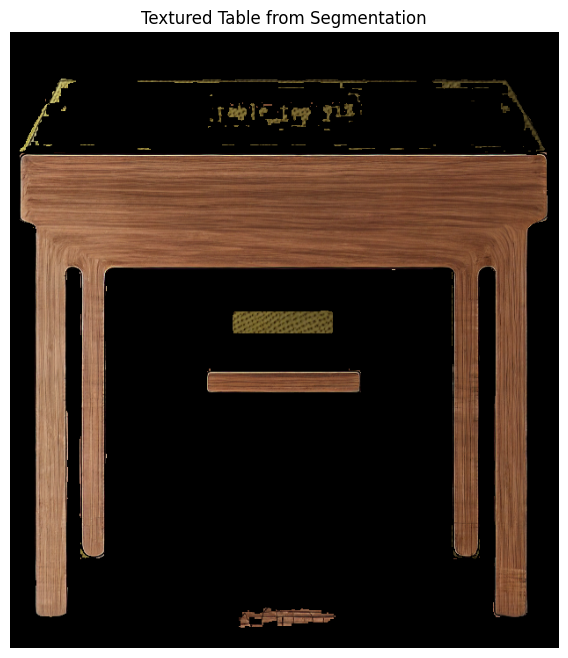

In [2]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Enable memory-saving option if available for your hardware
# You might need to install accelerate: !pip install accelerate
try:
    import accelerate
    accelerate.init_empty_weights()
    enable_low_memory = True
except ImportError:
    enable_low_memory = False
    print("Accelerate library not found. Low memory option disabled.")

def apply_textures_to_segments(segmentation_image_path):
    """
    Generate and apply textures directly from a segmentation image.
    No need for the original image since segmentation is already done.
    """
    # Load models
    controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16,
        # Enable low memory option if available
        low_cpu_mem_usage=enable_low_memory,
        variant="fp16" if enable_low_memory else None,
    )

    # Enable xformers for better memory efficiency
    pipe.enable_xformers_memory_efficient_attention()

    # Load segmentation image
    segmentation_image = cv2.imread('/Table.jpg')
    if segmentation_image is None:
        raise ValueError(f"Could not load segmentation image from {segmentation_image_path}")

    # Convert to HSV for color-based segmentation
    hsv = cv2.cvtColor(segmentation_image, cv2.COLOR_BGR2HSV)

    # Define segments with their colors and desired textures
    segments = [
        {
            "name": "tabletop",
            "color": {"lower": np.array([20, 100, 100]), "upper": np.array([40, 255, 255])},  # Yellow/gold color
            "prompt": "premium yellow, photorealistic, detailed surface structure, tabletop"
        },
        {
            "name": "tablelegs",
            "color": {
                "lower1": np.array([0, 100, 100]), "upper1": np.array([10, 255, 255]),      # Red lower range
                "lower2": np.array([160, 100, 100]), "upper2": np.array([180, 255, 255])    # Red upper range
            },
            "prompt": "polished dark walnut wood texture, table legs, photorealistic, smooth finish"
        }
    ]

    # Create a blank canvas for the final result (RGB)
    height, width = segmentation_image.shape[:2]
    result_image = np.zeros((height, width, 3), dtype=np.uint8)

    # Process each segment
    for segment in segments:
        print(f"Processing segment: {segment['name']}")

        # Create mask based on color
        if "lower1" in segment["color"]:  # For colors that wrap around HSV space (like red)
            mask1 = cv2.inRange(hsv, segment["color"]["lower1"], segment["color"]["upper1"])
            mask2 = cv2.inRange(hsv, segment["color"]["lower2"], segment["color"]["upper2"])
            mask = cv2.bitwise_or(mask1, mask2)
        else:
            mask = cv2.inRange(hsv, segment["color"]["lower"], segment["color"]["upper"])

        # Clean up mask with morphological operations
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Skip if no pixels in this segment
        if cv2.countNonZero(mask) == 0:
            print(f"No pixels found for segment: {segment['name']}")
            continue

        # Create a basic structure/shape image for the controlnet
        # We'll create a simple edge detection from the mask
        structure_image = np.zeros((height, width), dtype=np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(structure_image, contours, -1, 255, 2)

        # Add some internal structure if it's a large segment
        if cv2.countNonZero(mask) > 10000:  # Arbitrary threshold
            # Add some random lines or patterns inside for more interesting texture structure
            for i in range(10):
                pt1 = (np.random.randint(0, width), np.random.randint(0, height))
                pt2 = (np.random.randint(0, width), np.random.randint(0, height))
                if mask[pt1[1], pt1[0]] > 0 and mask[pt2[1], pt2[0]] > 0:
                    cv2.line(structure_image, pt1, pt2, 255, 1)

        # Convert to RGB for ControlNet
        structure_rgb = cv2.cvtColor(structure_image, cv2.COLOR_GRAY2RGB)

        # Generate texture using ControlNet
        # Move the pipeline to CUDA only before inference
        with torch.autocast("cuda"):
           pipe = pipe.to("cuda")
           texture = pipe(
               prompt=segment["prompt"],
               image=Image.fromarray(structure_rgb),
               num_inference_steps=30,
               guidance_scale=7.5
           ).images[0]

           # Move the pipeline back to CPU after inference
           pipe = pipe.to("cpu")

        # Convert to numpy array and resize to match original size
        texture_np = np.array(texture)
        texture_np = cv2.resize(texture_np, (width, height))

        # Apply texture to result image using the mask
        mask_3ch = np.stack([mask, mask, mask], axis=2) / 255.0
        result_image = result_image * (1 - mask_3ch) + texture_np * mask_3ch

        # Save individual textures (optional)
        cv2.imwrite(f"/{segment['name']}_texture.png", cv2.cvtColor(texture_np, cv2.COLOR_RGB2BGR))

    # Convert to uint8 before saving
    result_image = result_image.astype(np.uint8)

    # Save the final result
    cv2.imwrite("/textured_result.png", cv2.cvtColor(result_image, cv2.COLOR_RGB2BGR))
    print("Texture generation complete!")

    return result_image

# Run the function
segmentation_path = "/table_segmentation.png"
final_image = apply_textures_to_segments(segmentation_path)

# Display the result
plt.figure(figsize=(10, 8))
plt.imshow(final_image)
plt.axis('off')
plt.title("Textured Table from Segmentation")
plt.show()

In [12]:
!pip install xformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 536.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB ? eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 551.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 475.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Processing segment: tabletop
Generating texture for tabletop...


  0%|          | 0/30 [00:00<?, ?it/s]

Processing segment: tablelegs
Generating texture for tablelegs...


  0%|          | 0/30 [00:00<?, ?it/s]

Texture generation complete!


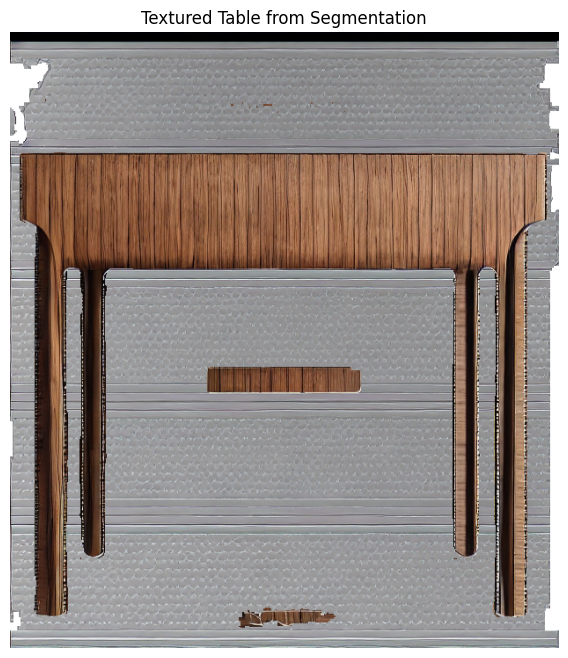

In [5]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def apply_textures_with_background(segmentation_image_path, background_color=(255, 255, 255)):
    """
    Generate and apply textures to segments while preserving a proper background.

    Args:
        segmentation_image_path: Path to the segmentation image
        background_color: RGB color to use for background (default: white)
    """
    # Load models
    controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16
    ).to("cuda")

    # Load segmentation image
    segmentation_image = cv2.imread(segmentation_image_path)
    if segmentation_image is None:
        raise ValueError(f"Could not load segmentation image from {segmentation_image_path}")

    # Convert to HSV for color-based segmentation
    hsv = cv2.cvtColor(segmentation_image, cv2.COLOR_BGR2HSV)

    # Define segments with their colors and desired textures
    segments = [
        {
            "name": "tabletop",
            # Adjusted color ranges for gold/yellowish top
            "color": {"lower": np.array([15, 50, 50]), "upper": np.array([45, 255, 255])},
            "prompt": "metal, photorealistic, detailed surface structure, tabletop"
        },
        {
            "name": "tablelegs",
            # Adjusted color ranges for red legs
            "color": {
                "lower1": np.array([0, 50, 50]), "upper1": np.array([10, 255, 255]),
                "lower2": np.array([160, 50, 50]), "upper2": np.array([180, 255, 255])
            },
            "prompt": "polished dark walnut wood texture, table legs, photorealistic, smooth finish"
        }
    ]

    # Create a background for the final result (RGB)
    height, width = segmentation_image.shape[:2]
    result_image = np.ones((height, width, 3), dtype=np.uint8) * np.array(background_color, dtype=np.uint8)

    # Track all masks combined to identify background
    all_masks_combined = np.zeros((height, width), dtype=np.uint8)

    # Process each segment
    for segment in segments:
        print(f"Processing segment: {segment['name']}")

        # Create mask based on color
        if "lower1" in segment["color"]:  # For colors that wrap around HSV space (like red)
            mask1 = cv2.inRange(hsv, segment["color"]["lower1"], segment["color"]["upper1"])
            mask2 = cv2.inRange(hsv, segment["color"]["lower2"], segment["color"]["upper2"])
            mask = cv2.bitwise_or(mask1, mask2)
        else:
            mask = cv2.inRange(hsv, segment["color"]["lower"], segment["color"]["upper"])

        # Clean up mask with morphological operations
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Update combined mask
        all_masks_combined = cv2.bitwise_or(all_masks_combined, mask)

        # Skip if no pixels in this segment
        if cv2.countNonZero(mask) == 0:
            print(f"No pixels found for segment: {segment['name']}")
            continue

        # Save the mask for debugging
        cv2.imwrite(f"/{segment['name']}_mask.png", mask)

        # Create a basic structure/shape image for the controlnet
        structure_image = np.zeros((height, width), dtype=np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Fill the structure with the segment shape
        filled_mask = np.zeros_like(mask)
        cv2.drawContours(filled_mask, contours, -1, 255, -1)  # Fill contours

        # Draw edges for structure guidance
        cv2.drawContours(structure_image, contours, -1, 255, 2)

        # Add some internal details for texture guidance
        if segment["name"] == "tabletop":
            # For table top add horizontal grain lines
            for y in range(0, height, 10):
                start_x, end_x = 0, width
                if np.any(filled_mask[y, :] > 0):
                    indices = np.where(filled_mask[y, :] > 0)[0]
                    if len(indices) > 0:
                        start_x, end_x = indices[0], indices[-1]
                        cv2.line(structure_image, (start_x, y), (end_x, y), 255, 1)
        else:
            # For legs add vertical grain lines
            for x in range(0, width, 15):
                column = filled_mask[:, x]
                if np.any(column > 0):
                    indices = np.where(column > 0)[0]
                    if len(indices) > 0:
                        start_y, end_y = indices[0], indices[-1]
                        cv2.line(structure_image, (x, start_y), (x, end_y), 255, 1)

        # Convert to RGB for ControlNet
        structure_rgb = cv2.cvtColor(structure_image, cv2.COLOR_GRAY2RGB)

        # Save structure image for debugging
        cv2.imwrite(f"/{segment['name']}_structure.png", structure_image)

        # Generate texture using ControlNet
        print(f"Generating texture for {segment['name']}...")
        texture = pipe(
            prompt=segment["prompt"],
            image=Image.fromarray(structure_rgb),
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]

        # Convert to numpy array and resize to match original size
        texture_np = np.array(texture)
        texture_np = cv2.resize(texture_np, (width, height))

        # Apply texture to result image using the filled mask
        mask_3ch = np.stack([filled_mask, filled_mask, filled_mask], axis=2) / 255.0
        result_image = result_image * (1 - mask_3ch) + texture_np * mask_3ch

        # Save individual textures (optional)
        texture.save(f"/{segment['name']}_texture.png")

    # Convert to uint8 before saving
    result_image = result_image.astype(np.uint8)

    # Save the final result
    pil_result = Image.fromarray(result_image)
    pil_result.save("/textured_result.png")
    print("Texture generation complete!")

    return result_image

# Run the function with a white background
segmentation_path = "/Table.jpg"
final_image = apply_textures_with_background(segmentation_path, background_color=(255, 255, 255))

# Display the result
plt.figure(figsize=(10, 8))
plt.imshow(final_image)
plt.axis('off')
plt.title("Textured Table from Segmentation")
plt.show()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Processing segment: tabletop
Generating texture for tabletop...


  0%|          | 0/30 [00:00<?, ?it/s]

Processing segment: tablelegs
Generating texture for tablelegs...


  0%|          | 0/30 [00:00<?, ?it/s]

Texture generation complete!


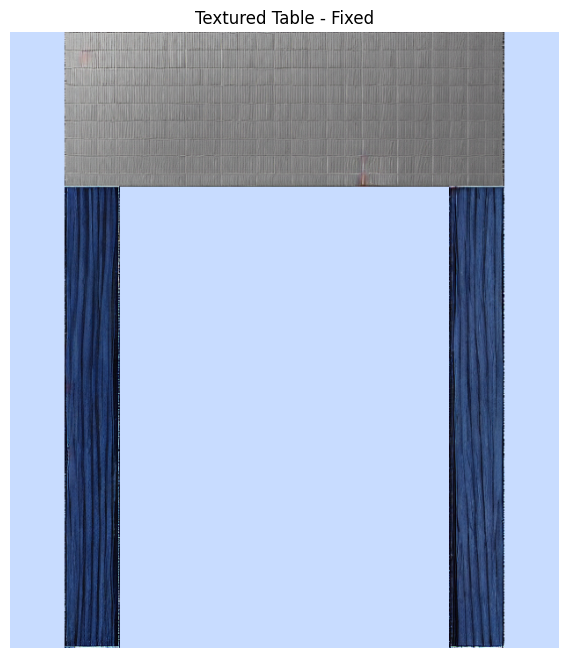

In [6]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def segment_using_text_labels(segmentation_image_path):
    """
    Generate masks based on the text labels in the segmentation image.
    This approach uses the position of labels rather than colors.
    """
    # Load segmentation image
    segmentation_image = cv2.imread(segmentation_image_path)
    if segmentation_image is None:
        raise ValueError(f"Could not load segmentation image from {segmentation_image_path}")

    height, width = segmentation_image.shape[:2]

    # Create empty masks
    tabletop_mask = np.zeros((height, width), dtype=np.uint8)
    tablelegs_mask = np.zeros((height, width), dtype=np.uint8)

    # Based on your image, we can see the clear regions:
    # - Table top: The gold/brown area at the top
    # - Table legs: The red areas on the sides
    # - Background: The peach color

    # 1. Process based on expected positions using your image

    # Table top (gold/brown) - top area of the image
    # The table_top is labeled in the gold area at the top
    table_top_region = {
        "top": 0,
        "bottom": int(height * 0.25),  # Top 25% of image
        "left": int(width * 0.1),
        "right": int(width * 0.9)
    }

    # Create mask for table top region
    cv2.rectangle(tabletop_mask,
                 (table_top_region["left"], table_top_region["top"]),
                 (table_top_region["right"], table_top_region["bottom"]),
                 255, -1)

    # Table legs (red) - vertical elements
    table_legs_regions = [
        # Left leg
        {"top": int(height * 0.25), "bottom": height,
         "left": int(width * 0.1), "right": int(width * 0.2)},
        # Right leg
        {"top": int(height * 0.25), "bottom": height,
         "left": int(width * 0.8), "right": int(width * 0.9)}
    ]

    # Create mask for table legs
    for region in table_legs_regions:
        cv2.rectangle(tablelegs_mask,
                     (region["left"], region["top"]),
                     (region["right"], region["bottom"]),
                     255, -1)

    # 2. Also try color-based segmentation as a complement

    # Convert to HSV for color detection
    hsv = cv2.cvtColor(segmentation_image, cv2.COLOR_BGR2HSV)

    # Detect gold/brown (table top)
    # Use a tighter range than before
    gold_lower = np.array([20, 100, 100])
    gold_upper = np.array([40, 255, 255])
    gold_mask = cv2.inRange(hsv, gold_lower, gold_upper)

    # Detect red (table legs)
    red_lower1 = np.array([0, 100, 100])
    red_upper1 = np.array([10, 255, 255])
    red_lower2 = np.array([160, 100, 100])
    red_upper2 = np.array([180, 255, 255])
    red_mask1 = cv2.inRange(hsv, red_lower1, red_upper1)
    red_mask2 = cv2.inRange(hsv, red_lower2, red_upper2)
    red_mask = cv2.bitwise_or(red_mask1, red_mask2)

    # Combine approaches: Use our position-based masks but enhance with color detection
    # where they overlap
    tabletop_mask = cv2.bitwise_or(tabletop_mask, cv2.bitwise_and(gold_mask, tabletop_mask))
    tablelegs_mask = cv2.bitwise_or(tablelegs_mask, cv2.bitwise_and(red_mask, tablelegs_mask))

    # Save masks for inspection
    cv2.imwrite("/tabletop_mask_fixed.png", tabletop_mask)
    cv2.imwrite("/tablelegs_mask_fixed.png", tablelegs_mask)

    return tabletop_mask, tablelegs_mask

def generate_and_apply_textures(segmentation_image_path):
    """Generate textures and apply them using the text-label based segmentation"""

    # Load models
    controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16
    ).to("cuda")

    # Get masks using our text-label approach
    tabletop_mask, tablelegs_mask = segment_using_text_labels(segmentation_image_path)

    # Load segmentation image for size reference and final composition
    segmentation_image = cv2.imread(segmentation_image_path)
    height, width = segmentation_image.shape[:2]

    # Create segments with masks and prompts
    segments = [
        {
            "name": "tabletop",
            "mask": tabletop_mask,
            "prompt": "metal surface, photorealistic, detailed surface structure, tabletop, brushed steel"
        },
        {
            "name": "tablelegs",
            "mask": tablelegs_mask,
            "prompt": "polished dark walnut wood texture, table legs, photorealistic, smooth finish, vertical grain"
        }
    ]

    # Create result image with background color (peach/cream color)
    # Using a color similar to your segmentation background
    background_color = [255, 220, 200]  # Light peach color
    result_image = np.ones((height, width, 3), dtype=np.uint8) * np.array(background_color, dtype=np.uint8)

    # Process each segment
    for segment in segments:
        print(f"Processing segment: {segment['name']}")
        mask = segment["mask"]

        # Skip if mask is empty
        if cv2.countNonZero(mask) == 0:
            print(f"Warning: No pixels found for {segment['name']}!")
            continue

        # Create control image for structure guidance
        structure_image = np.zeros((height, width), dtype=np.uint8)

        # Add appropriate structure details
        if segment["name"] == "tabletop":
            # For metal table top, add circular/grid pattern
            for y in range(0, height, 20):
                cv2.line(structure_image, (0, y), (width, y), 255, 1)
            for x in range(0, width, 20):
                cv2.line(structure_image, (x, 0), (x, height), 255, 1)
        else:
            # For wooden legs, add vertical grain lines
            for x in range(0, width, 10):
                cv2.line(structure_image, (x, 0), (x, height), 255, 1)

        # Apply mask to structure image
        structure_image = cv2.bitwise_and(structure_image, structure_image, mask=mask)

        # Add the contours for better shape guidance
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(structure_image, contours, -1, 255, 2)

        # Convert to RGB for ControlNet
        structure_rgb = cv2.cvtColor(structure_image, cv2.COLOR_GRAY2RGB)

        # Save structure guidance for debugging
        cv2.imwrite(f"/{segment['name']}_structure_fixed.png", structure_image)

        # Generate texture
        print(f"Generating texture for {segment['name']}...")
        texture = pipe(
            prompt=segment["prompt"],
            image=Image.fromarray(structure_rgb),
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]

        # Convert texture to numpy array
        texture_np = np.array(texture)
        texture_np = cv2.resize(texture_np, (width, height))

        # Apply texture to result using the mask
        mask_3ch = np.stack([mask, mask, mask], axis=2) / 255.0
        result_image = result_image * (1 - mask_3ch) + texture_np * mask_3ch

        # Save individual texture
        texture.save(f"/{segment['name']}_texture_fixed.png")

    # Save and return the final result
    result_image = result_image.astype(np.uint8)
    cv2.imwrite("/textured_table_final.png", cv2.cvtColor(result_image, cv2.COLOR_RGB2BGR))
    print("Texture generation complete!")

    return result_image

# Run the function
segmentation_path = "/Table.jpg"
final_image = generate_and_apply_textures(segmentation_path)

# Display the result
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Textured Table - Fixed")
plt.show()

In [ ]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def apply_textures_to_original_image(original_image_path, segmentation_image_path):
    """
    Generate textures based on segmentation and apply them to the original image.

    Args:
        original_image_path: Path to the original table image
        segmentation_image_path: Path to the segmentation image
    """
    # Load models
    controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16
    ).to("cuda")

    # Load the original image
    original_image = cv2.imread(original_image_path)
    if original_image is None:
        raise ValueError(f"Could not load original image from {original_image_path}")

    # Load segmentation image
    segmentation_image = cv2.imread(segmentation_image_path)
    if segmentation_image is None:
        raise ValueError(f"Could not load segmentation image from {segmentation_image_path}")

    # Get the dimensions
    height, width = original_image.shape[:2]

    # Extract masks from segmentation
    # Converting to HSV for more effective color segmentation
    hsv = cv2.cvtColor(segmentation_image, cv2.COLOR_BGR2HSV)

    # Create masks for table top (gold/yellow) and legs (red)
    # Table top - gold/yellow area
    gold_lower = np.array([20, 50, 50])
    gold_upper = np.array([40, 255, 255])
    tabletop_mask = cv2.inRange(hsv, gold_lower, gold_upper)

    # Table legs - red area
    red_lower1 = np.array([0, 50, 50])
    red_upper1 = np.array([10, 255, 255])
    red_lower2 = np.array([160, 50, 50])
    red_upper2 = np.array([180, 255, 255])
    red_mask1 = cv2.inRange(hsv, red_lower1, red_upper1)
    red_mask2 = cv2.inRange(hsv, red_lower2, red_upper2)
    tablelegs_mask = cv2.bitwise_or(red_mask1, red_mask2)

    # Clean up masks
    kernel = np.ones((5, 5), np.uint8)
    tabletop_mask = cv2.morphologyEx(tabletop_mask, cv2.MORPH_CLOSE, kernel)
    tablelegs_mask = cv2.morphologyEx(tablelegs_mask, cv2.MORPH_CLOSE, kernel)

    # If masks are empty or too small, use position-based segmentation as fallback
    if cv2.countNonZero(tabletop_mask) < 1000:
        print("Table top mask too small, using position-based segmentation instead")
        tabletop_mask = np.zeros((height, width), dtype=np.uint8)
        # Define top portion of image as table top (adjust as needed)
        cv2.rectangle(tabletop_mask, (0, 0), (width, int(height * 0.25)), 255, -1)

    if cv2.countNonZero(tablelegs_mask) < 1000:
        print("Table legs mask too small, using position-based segmentation instead")
        tablelegs_mask = np.zeros((height, width), dtype=np.uint8)
        # Define left and right vertical strips as table legs
        leg_width = int(width * 0.1)
        cv2.rectangle(tablelegs_mask, (int(width * 0.1), int(height * 0.25)),
                     (int(width * 0.2), height), 255, -1)  # Left leg
        cv2.rectangle(tablelegs_mask, (int(width * 0.8), int(height * 0.25)),
                     (int(width * 0.9), height), 255, -1)  # Right leg

    # Save masks for debugging
    cv2.imwrite("/tabletop_mask.png", tabletop_mask)
    cv2.imwrite("/tablelegs_mask.png", tablelegs_mask)

    # Define segments with their masks and prompts
    segments = [
        {
            "name": "tabletop",
            "mask": tabletop_mask,
            "prompt": "metal surface texture, photorealistic, brushed steel, detailed surface structure, tabletop"
        },
        {
            "name": "tablelegs",
            "mask": tablelegs_mask,
            "prompt": "polished dark walnut wood texture, table legs, photorealistic, smooth finish, vertical grain"
        }
    ]

    # Create a copy of the original image to work with
    result_image = original_image.copy()

    # Process each segment
    for segment in segments:
        print(f"Processing segment: {segment['name']}")
        mask = segment["mask"]

        # Skip if mask is empty
        if cv2.countNonZero(mask) == 0:
            print(f"Warning: No pixels found for {segment['name']}!")
            continue

        # Create control image for structure guidance
        structure_image = np.zeros((height, width), dtype=np.uint8)

        # Extract the segment from the original image to get its structure
        segment_region = cv2.bitwise_and(original_image, original_image, mask=mask)

        # Create edge detection for structure guidance
        gray_segment = cv2.cvtColor(segment_region, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray_segment, 50, 150)

        # Add appropriate structure details
        if segment["name"] == "tabletop":
            # For metal table top, add grid pattern on top of edges
            for y in range(0, height, 20):
                cv2.line(structure_image, (0, y), (width, y), 128, 1)
            for x in range(0, width, 20):
                cv2.line(structure_image, (x, 0), (x, height), 128, 1)
        else:
            # For wooden legs, add vertical grain lines
            for x in range(0, width, 10):
                cv2.line(structure_image, (x, 0), (x, height), 128, 1)

        # Combine edges with pattern
        structure_image = cv2.bitwise_or(edges, structure_image)

        # Apply mask to structure image
        structure_image = cv2.bitwise_and(structure_image, structure_image, mask=mask)

        # Add the contours for better shape guidance
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(structure_image, contours, -1, 255, 2)

        # Convert to RGB for ControlNet
        structure_rgb = cv2.cvtColor(structure_image, cv2.COLOR_GRAY2RGB)

        # Save structure guidance for debugging
        cv2.imwrite(f"/{segment['name']}_structure.png", structure_image)

        # Generate texture
        print(f"Generating texture for {segment['name']}...")
        texture = pipe(
            prompt=segment["prompt"],
            image=Image.fromarray(structure_rgb),
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]

        # Convert texture to numpy array
        texture_np = np.array(texture)
        texture_np = cv2.cvtColor(texture_np, cv2.COLOR_RGB2BGR)  # Convert RGB to BGR for OpenCV
        texture_np = cv2.resize(texture_np, (width, height))

        # Apply texture to result using the mask
        mask_3ch = np.stack([mask, mask, mask], axis=2) / 255.0
        result_image = result_image * (1 - mask_3ch) + texture_np * mask_3ch

        # Save individual texture
        cv2.imwrite(f"/{segment['name']}_texture.png", cv2.cvtColor(np.array(texture), cv2.COLOR_RGB2BGR))

    # Save and return the final result
    cv2.imwrite("/textured_original_table.png", result_image)
    print("Texture application complete!")

    return result_image

# Run the function
original_image_path = "/Table.jpg"  # Path to your original table image
segmentation_path = "/table_segmentation.png"  # Path to your segmentation image
final_image = apply_textures_to_original_image(original_image_path, segmentation_path)

# Display the result
plt.figure(figsize=(12, 10))

plt.subplot(1, 2, 1)
original = cv2.imread(original_image_path)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
plt.title("Textured Result")
plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
!pip install roboflow

In [2]:
from roboflow import Roboflow

def download_roboflow_dataset(api_key, workspace_id, project_id, version_id):
    """Download a dataset from Roboflow and return its path"""
    rf = Roboflow(api_key=api_key)
    project = rf.workspace(workspace_id).project(project_id)
    dataset = project.version(version_id).download("coco-segmentation")

    print(f"Dataset downloaded to: {dataset.location}")
    return dataset.location

api_key = "SN5wJh6Iq1qReYz1KzDq"  # Replace with your actual API key
workspace_id = "interiorfurniture"     # Replace with your workspace name
project_id = "table-segmentation-zvc3i"  # Replace with your project name
version_id = 1

# Download the dataset
dataset_path = download_roboflow_dataset(api_key, workspace_id, project_id, version_id)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to table-segmentation-1 in coco-segmentation:: 100%|██████████| 114/114 [00:00<00:00, 2765.60it/s]

Dataset downloaded to: /content/table-segmentation-1


Available images: ['67_jpg.rf.8e03b1cc181da30fc1e693cdede0daaf.jpg', '12_jpg.rf.f93f46d020df3e1950fdace36a879563.jpg', '87_jpg.rf.02ebd9c88358a7daecfef9b6ab3b2331.jpg', '-_jpg.rf.f1b3e53e94080da2efaa39ab28188d85.jpg', '4_jpg.rf.4472f6c5732b038ddcc591d5fe1b0e24.jpg', '121_jpg.rf.ba2694beb3f01ac106d053958bf472b0.jpg', '139_jpg.rf.efaca36556363aea20c714e8963a668d.jpg', '108_jpg.rf.8386c630ea020dbb48a44e1942b93efd.jpg', '97_jpg.rf.7935845b0b32b0e60bef57cf6877854e.jpg', '23_jpg.rf.c1224dec18503744aad72ecdff278631.jpg', '13_jpg.rf.e5bf934203c634ab2a6eb44dc725dc43.jpg', '105_jpg.rf.2d91595b14ba0b2e3fd25926357a7947.jpg', '85_jpg.rf.1cbf2a14cf136e00086994b9cf91b173.jpg', 'table2_jpg.rf.3084c16a650ddbdb0eaeef809917ee7c.jpg', 'table7_jpg.rf.fde3ccfd087e5b72105b087000e86163.jpg', 'images-5-_jpg.rf.ec42fe9133077399a98ef5c7341a5389.jpg', '65_jpg.rf.d1e5b9bc726a6916c2bd01a93e257abf.jpg', 'table6_jpg.rf.b60ca3ff51eb501a80cb528e45da7560.jpg', '131_jpg.rf.70bdcdb8ff4ec75449679c553f1fc7ea.jpg', '32_jpg.r

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Processing table, instance 1/3


  0%|          | 0/30 [00:00<?, ?it/s]

Processing table_top, instance 2/3


  0%|          | 0/30 [00:00<?, ?it/s]

Processing table_legs, instance 3/3


  0%|          | 0/30 [00:00<?, ?it/s]

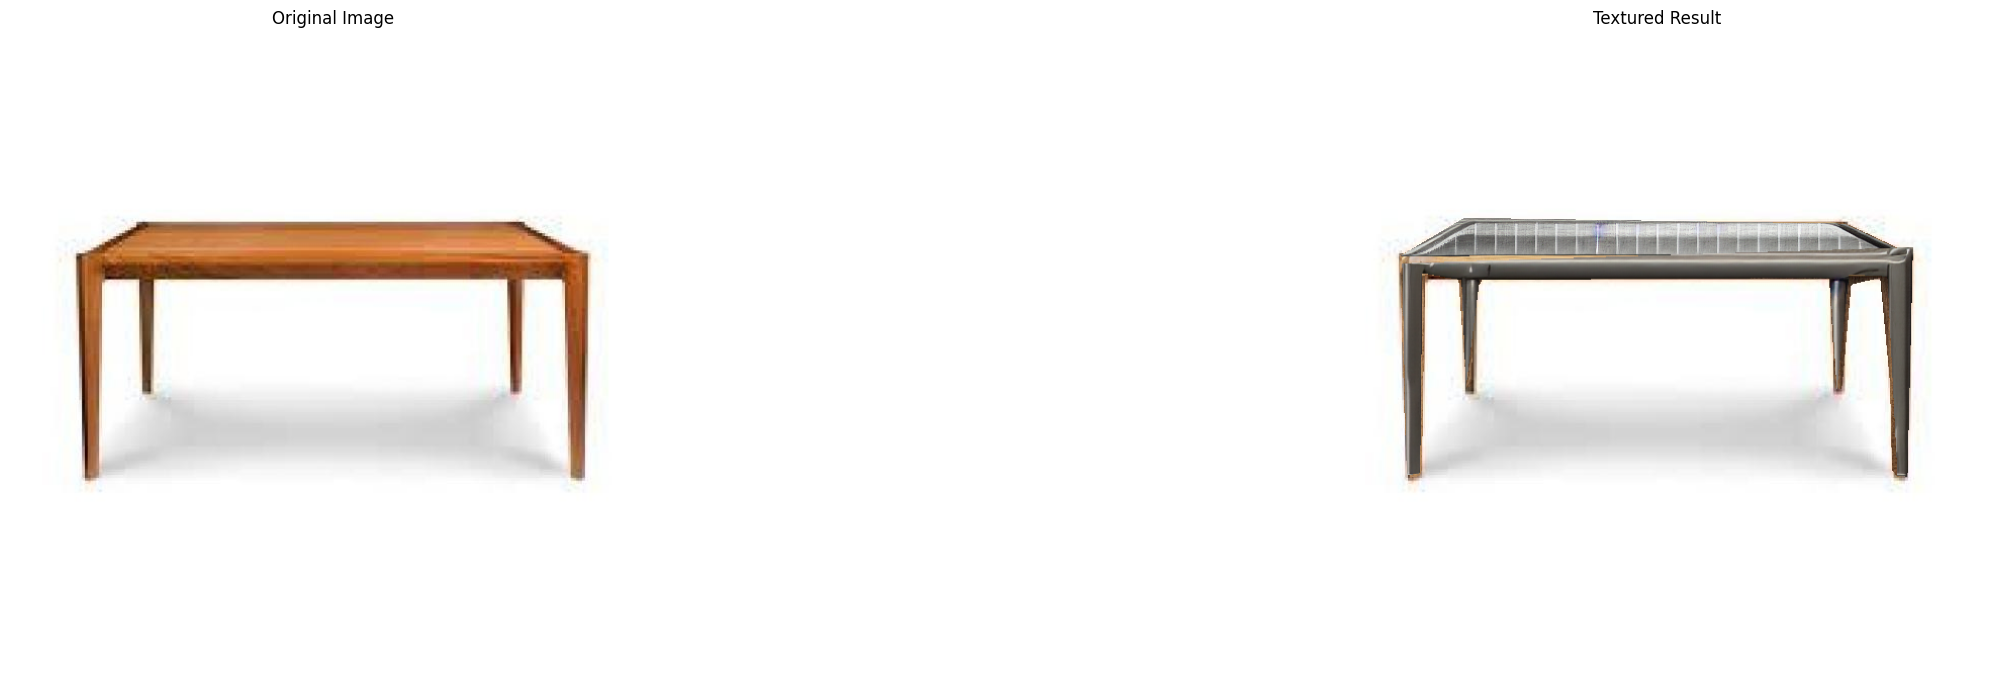

Processing completed successfully!


In [9]:
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import json
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from pycocotools.coco import COCO

def apply_textures_with_roboflow_segmentation(
    dataset_path,
    image_filename,
    material_prompts=None
):
    """
    Apply textures to an image using Roboflow segmentation annotations.

    Args:
        dataset_path: Path to the downloaded Roboflow dataset
        image_filename: Filename of the image in the dataset to process
        material_prompts: Dict mapping class names to texture prompts
    """
    # Default material prompts if none provided
    if material_prompts is None:
        material_prompts = {
            "table": "polished wood grain texture, rich brown color, detailed surface",
            "chair": "fabric texture, beige upholstery, soft material",
            "sofa": "leather texture, dark brown, detailed seams",
            "cabinet": "painted wood texture, white matte finish, smooth surface",
            "desk": "mahogany wood texture, deep red tones, glossy finish",
            "default": "neutral material texture, photorealistic surface"
        }

    # Set up paths
    coco_annotation_file = os.path.join(dataset_path, "train", "_annotations.coco.json")
    image_path = os.path.join(dataset_path, "train", image_filename)

    # Check if files exist
    if not os.path.exists(coco_annotation_file):
        raise FileNotFoundError(f"Annotation file not found: {coco_annotation_file}")
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")

    # Load COCO annotations
    coco = COCO(coco_annotation_file)

    # Get image info
    img_info = None
    for img in coco.loadImgs(coco.getImgIds()):
        if img['file_name'] == image_filename:
            img_info = img
            break

    if img_info is None:
        raise ValueError(f"Image {image_filename} not found in the dataset annotations")

    # Load the image
    original_image = cv2.imread(image_path)
    if original_image is None:
        raise ValueError(f"Could not load image: {image_path}")

    # Ensure the original image is uint8
    if original_image.dtype != np.uint8:
        print(f"Warning: Converting original image from {original_image.dtype} to uint8")
        original_image = (np.clip(original_image, 0, 255)).astype(np.uint8)

    original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    height, width = original_image.shape[:2]

    # Get annotations for this image
    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)

    # Print found categories to help with debugging
    cat_names = [coco.loadCats([ann['category_id']])[0]['name'] for ann in anns]
    print(f"Found categories in image: {cat_names}")

    # Prepare for visualization
    segmentation_vis = original_rgb.copy()

    # Initialize ControlNet for texture generation
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/sd-controlnet-canny",
        torch_dtype=torch.float16
    )

    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16
    ).to("cuda")

    # Create a copy of the original image to apply textures to
    result_image = original_image.copy()

    # Store all masks to visualize
    all_masks = []
    all_textures = []

    # Process each annotation (instance)
    for i, ann in enumerate(anns):
        # Get category name
        cat_id = ann['category_id']
        cat_info = coco.loadCats([cat_id])[0]
        cat_name = cat_info['name']

        print(f"Processing {cat_name}, instance {i+1}/{len(anns)}")

        # Create mask from segmentation
        mask = coco.annToMask(ann)
        mask_uint8 = mask.astype(np.uint8) * 255
        all_masks.append((cat_name, mask_uint8))

        # Generate appropriate texture prompt based on category
        prompt = material_prompts.get(cat_name, material_prompts['default'])

        # Create structure guidance for texture generation
        # Extract the region
        region = cv2.bitwise_and(original_image, original_image, mask=mask_uint8)

        # Get edges for structure guidance
        gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)

        # Add texture-specific structure patterns
        if "wood" in prompt.lower():
            # Add wood grain pattern
            if "vertical" in prompt.lower():
                # Vertical grain (for legs, etc.)
                for x in range(0, width, 10):
                    cv2.line(edges, (x, 0), (x, height), 128, 1)
            else:
                # Horizontal grain (for tops, etc.)
                for y in range(0, height, 10):
                    cv2.line(edges, (0, y), (width, y), 128, 1)
        elif "metal" in prompt.lower():
            # Add metal pattern (grid)
            for y in range(0, height, 20):
                cv2.line(edges, (0, y), (width, y), 100, 1)
            for x in range(0, width, 20):
                cv2.line(edges, (x, 0), (x, height), 100, 1)
        elif "fabric" in prompt.lower() or "leather" in prompt.lower():
            # Add subtle fabric/leather texture pattern
            for y in range(0, height, 5):
                for x in range(0, width, 5):
                    if (x + y) % 10 == 0:
                        cv2.circle(edges, (x, y), 1, 100, -1)

        # Apply mask to edges
        edges = cv2.bitwise_and(edges, edges, mask=mask_uint8)

        # Convert to RGB for ControlNet
        edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

        # Save edge guidance for debugging
        output_dir = "/content"  # Update this to your preferred output directory
        cv2.imwrite(f"{output_dir}/structure_{cat_name}_{i}.png", edges)

        # Generate texture
        enhanced_prompt = f"{prompt}, seamless texture, detailed surface structure, photorealistic material, high resolution"
        texture = pipe(
            enhanced_prompt,
            image=Image.fromarray(edges_rgb),
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]

        # Save the texture
        texture.save(f"{output_dir}/texture_{cat_name}_{i}.png")

        # Store for visualization
        texture_np = np.array(texture)
        all_textures.append((cat_name, texture_np))

        # Apply texture to result image
        texture_np_bgr = cv2.cvtColor(texture_np, cv2.COLOR_RGB2BGR)
        texture_np_bgr = cv2.resize(texture_np_bgr, (width, height))
        mask_3ch = np.stack([mask_uint8, mask_uint8, mask_uint8], axis=2) / 255.0
        result_image = result_image * (1 - mask_3ch) + texture_np_bgr * mask_3ch

    # Ensure result image is uint8 before color conversion
    result_image = np.clip(result_image, 0, 255).astype(np.uint8)

    # Convert result to RGB for display
    result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

    # Save the result
    output_dir = "/content"  # Update this to your preferred output directory
    cv2.imwrite(f"{output_dir}/textured_result_{os.path.splitext(image_filename)[0]}.png", result_image)

    # Visualize results
    fig = plt.figure(figsize=(20, 10))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(original_rgb)
    plt.title("Original Image")
    plt.axis('off')

    # Segmentation masks
    # plt.subplot(1, 3, 2)
    segmentation_display = original_rgb.copy()
    colors = np.random.randint(0, 255, size=(len(anns), 3), dtype=np.uint8)

    for i, ann in enumerate(anns):
        mask = coco.annToMask(ann)
        color_mask = np.zeros_like(original_rgb)
        color_mask[mask == 1] = colors[i]

        # Apply colored mask
        alpha = 0.6
        segmentation_display = cv2.addWeighted(
            segmentation_display, 1, color_mask, alpha, 0
        )

        # Add label
        cat_name = coco.loadCats([ann['category_id']])[0]['name']
        x, y, w, h = ann['bbox']
        cv2.putText(segmentation_display, cat_name, (int(x), int(y)-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.9, colors[i].tolist(), 2)

    # plt.imshow(segmentation_display)
    # plt.title("Segmentation Masks")
    # plt.axis('off')

    # Result with applied textures
    plt.subplot(1, 3, 3)
    plt.imshow(result_rgb)
    plt.title("Textured Result")
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/visualization_{os.path.splitext(image_filename)[0]}.png")
    plt.show()

    return result_image, all_masks, all_textures

# Material prompts mapping categories to texture descriptions
material_prompts = {
    "table": "wooden table surface texture, oak finish, natural grain pattern",
    "table_top": "metal surface texture, brushed aluminum, like mirror ",
    "table_leg": "polished dark walnut wood texture, vertical grain, smooth finish",
    "chair": "fabric texture, blue upholstery with subtle pattern",
    "sofa": "leather texture, dark brown, with stitching details",
    "cabinet": "white painted wood texture, matte finish, smooth surface",
    "default": "generic material texture, neutral color, photorealistic"
}

# Use your pre-downloaded dataset path
dataset_path = "/content/table-segmentation-1"  # Update this to your dataset path

# List available images
train_folder = os.path.join(dataset_path, "train")
available_images = [f for f in os.listdir(train_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
print(f"Available images: {available_images}")

# Select an image to process
if available_images:
    selected_image = available_images[0]  # Use the first image as an example
    print(f"Selected image: {selected_image}")

    # Process the image with instance segmentation and texture application
    try:
        result_image, masks, textures = apply_textures_with_roboflow_segmentation(
            dataset_path,
            selected_image,
            material_prompts
        )
        print("Processing completed successfully!")
    except Exception as e:
        print(f"Error during processing: {str(e)}")
        import traceback
        traceback.print_exc()
else:
    print("No images found in the dataset train folder.")

In [4]:
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import json
import time
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from pycocotools.coco import COCO
from tqdm import tqdm
import argparse

def apply_textures_to_multiple_images(
    dataset_path,
    output_dir="/content/output",
    material_prompts=None,
    max_images=None,
    skip_existing=True
):
    """
    Apply textures to multiple images in the dataset using Roboflow segmentation annotations.

    Args:
        dataset_path: Path to the downloaded Roboflow dataset
        output_dir: Directory to save the results
        material_prompts: Dict mapping class names to texture prompts
        max_images: Maximum number of images to process (None for all)
        skip_existing: Whether to skip images that have already been processed
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Default material prompts if none provided
    if material_prompts is None:
        material_prompts = {
            "table": "polished wood grain texture, rich brown color, detailed surface",
            "chair": "fabric texture, beige upholstery, soft material",
            "sofa": "leather texture, dark brown, detailed seams",
            "cabinet": "painted wood texture, white matte finish, smooth surface",
            "desk": "mahogany wood texture, deep red tones, glossy finish",
            "default": "neutral material texture, photorealistic surface"
        }

    # List available images
    train_folder = os.path.join(dataset_path, "train")
    available_images = [f for f in os.listdir(train_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

    if max_images is not None:
        available_images = available_images[:max_images]

    print(f"Found {len(available_images)} images to process")

    # Initialize ControlNet and StableDiffusion pipeline (load once for all images)
    print("Loading ControlNet model...")
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/sd-controlnet-canny",
        torch_dtype=torch.float16
    )

    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16
    ).to("cuda")

    # Track processing results
    successful_images = 0
    failed_images = []
    skipped_images = 0

    # Start time
    start_time = time.time()

    # Process each image one by one
    for idx, image_filename in enumerate(tqdm(available_images, desc="Processing images")):
        image_basename = os.path.splitext(image_filename)[0]
        result_path = os.path.join(output_dir, f"textured_result_{image_basename}.png")

        # Check if result already exists and skip if needed
        if skip_existing and os.path.exists(result_path):
            print(f"Skipping {image_filename} - already processed")
            skipped_images += 1
            continue

        print(f"\n[{idx+1}/{len(available_images)}] Processing image: {image_filename}")

        try:
            # Create subfolder for this image's outputs
            image_output_dir = os.path.join(output_dir, image_basename)
            os.makedirs(image_output_dir, exist_ok=True)

            # Process the image
            result_image, masks, textures = apply_textures_with_roboflow_segmentation(
                dataset_path,
                image_filename,
                material_prompts,
                pipe,
                image_output_dir
            )

            # Save the final result to main output directory
            cv2.imwrite(result_path, result_image)

            print(f"Successfully processed image: {image_filename}")
            successful_images += 1

        except Exception as e:
            print(f"Error processing image {image_filename}: {str(e)}")
            failed_images.append((image_filename, str(e)))
            import traceback
            traceback.print_exc()

        # Free up CUDA memory between images
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Calculate elapsed time
    end_time = time.time()
    elapsed_time = end_time - start_time
    hours, remainder = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print summary
    print("\n" + "="*50)
    print(f"Processing Summary:")
    print(f"Total images: {len(available_images)}")
    print(f"Successfully processed: {successful_images}")
    print(f"Failed: {len(failed_images)}")
    print(f"Skipped (already existed): {skipped_images}")
    print(f"Total time: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

    if successful_images > 0:
        print(f"Average time per successful image: {elapsed_time / successful_images:.2f}s")

    if failed_images:
        print("\nFailed images:")
        for name, error in failed_images:
            print(f"- {name}: {error}")

    return successful_images, failed_images, skipped_images

def apply_textures_with_roboflow_segmentation(
    dataset_path,
    image_filename,
    material_prompts,
    pipe=None,  # Pass the pipeline to avoid reloading for each image
    output_dir="/content"
):
    """
    Apply textures to an image using Roboflow segmentation annotations.

    Args:
        dataset_path: Path to the downloaded Roboflow dataset
        image_filename: Filename of the image in the dataset to process
        material_prompts: Dict mapping class names to texture prompts
        pipe: StableDiffusionControlNetPipeline instance (if None, will create new one)
        output_dir: Directory to save outputs
    """
    # Set up paths
    coco_annotation_file = os.path.join(dataset_path, "train", "_annotations.coco.json")
    image_path = os.path.join(dataset_path, "train", image_filename)

    # Check if files exist
    if not os.path.exists(coco_annotation_file):
        raise FileNotFoundError(f"Annotation file not found: {coco_annotation_file}")
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")

    # Load COCO annotations
    coco = COCO(coco_annotation_file)

    # Get image info
    img_info = None
    for img in coco.loadImgs(coco.getImgIds()):
        if img['file_name'] == image_filename:
            img_info = img
            break

    if img_info is None:
        raise ValueError(f"Image {image_filename} not found in the dataset annotations")

    # Load the image
    original_image = cv2.imread(image_path)
    if original_image is None:
        raise ValueError(f"Could not load image: {image_path}")

    # Ensure the original image is uint8
    if original_image.dtype != np.uint8:
        print(f"Warning: Converting original image from {original_image.dtype} to uint8")
        original_image = (np.clip(original_image, 0, 255)).astype(np.uint8)

    original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    height, width = original_image.shape[:2]

    # Get annotations for this image
    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)

    if not anns:
        print(f"Warning: No annotations found for image {image_filename}")
        return original_image, [], []  # Return original image if no annotations

    # Print found categories to help with debugging
    cat_names = [coco.loadCats([ann['category_id']])[0]['name'] for ann in anns]
    print(f"Found categories in image: {cat_names}")

    # Initialize ControlNet for texture generation if not provided
    if pipe is None:
        print("Loading ControlNet model (this should be avoided for batch processing)...")
        controlnet = ControlNetModel.from_pretrained(
            "lllyasviel/sd-controlnet-canny",
            torch_dtype=torch.float16
        )

        pipe = StableDiffusionControlNetPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            controlnet=controlnet,
            torch_dtype=torch.float16
        ).to("cuda")

    # Create a copy of the original image to apply textures to
    result_image = original_image.copy()

    # Store all masks to visualize
    all_masks = []
    all_textures = []

    # Process each annotation (instance)
    for i, ann in enumerate(anns):
        # Get category name
        cat_id = ann['category_id']
        cat_info = coco.loadCats([cat_id])[0]
        cat_name = cat_info['name']

        print(f"Processing {cat_name}, instance {i+1}/{len(anns)}")

        # Create mask from segmentation
        mask = coco.annToMask(ann)
        mask_uint8 = mask.astype(np.uint8) * 255
        all_masks.append((cat_name, mask_uint8))

        # Generate appropriate texture prompt based on category
        prompt = material_prompts.get(cat_name, material_prompts['default'])

        # Create structure guidance for texture generation
        # Extract the region
        region = cv2.bitwise_and(original_image, original_image, mask=mask_uint8)

        # Get edges for structure guidance
        gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)

        # Add texture-specific structure patterns
        if "wood" in prompt.lower():
            # Add wood grain pattern
            if "vertical" in prompt.lower():
                # Vertical grain (for legs, etc.)
                for x in range(0, width, 10):
                    cv2.line(edges, (x, 0), (x, height), 128, 1)
            else:
                # Horizontal grain (for tops, etc.)
                for y in range(0, height, 10):
                    cv2.line(edges, (0, y), (width, y), 128, 1)
        elif "metal" in prompt.lower():
            # Add metal pattern (grid)
            for y in range(0, height, 20):
                cv2.line(edges, (0, y), (width, y), 100, 1)
            for x in range(0, width, 20):
                cv2.line(edges, (x, 0), (x, height), 100, 1)
        elif "fabric" in prompt.lower() or "leather" in prompt.lower():
            # Add subtle fabric/leather texture pattern
            for y in range(0, height, 5):
                for x in range(0, width, 5):
                    if (x + y) % 10 == 0:
                        cv2.circle(edges, (x, y), 1, 100, -1)

        # Apply mask to edges
        edges = cv2.bitwise_and(edges, edges, mask=mask_uint8)

        # Convert to RGB for ControlNet
        edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

        # Save edge guidance for debugging
        cv2.imwrite(f"{output_dir}/structure_{cat_name}_{i}.png", edges)

        # Generate texture
        enhanced_prompt = f"{prompt}, seamless texture, detailed surface structure, photorealistic material, high resolution"
        texture = pipe(
            enhanced_prompt,
            image=Image.fromarray(edges_rgb),
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]

        # Save the texture
        texture.save(f"{output_dir}/texture_{cat_name}_{i}.png")

        # Store for visualization
        texture_np = np.array(texture)
        all_textures.append((cat_name, texture_np))

        # Apply texture to result image
        texture_np_bgr = cv2.cvtColor(texture_np, cv2.COLOR_RGB2BGR)
        texture_np_bgr = cv2.resize(texture_np_bgr, (width, height))
        mask_3ch = np.stack([mask_uint8, mask_uint8, mask_uint8], axis=2) / 255.0
        result_image = result_image * (1 - mask_3ch) + texture_np_bgr * mask_3ch

    # Ensure result image is uint8 before color conversion
    result_image = np.clip(result_image, 0, 255).astype(np.uint8)

    # Convert result to RGB for display
    result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

    # Create visualization
    fig = plt.figure(figsize=(20, 10))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(original_rgb)
    plt.title("Original Image")
    plt.axis('off')

    # Segmentation masks
    plt.subplot(1, 3, 2)
    segmentation_display = original_rgb.copy()
    colors = np.random.randint(0, 255, size=(len(anns), 3), dtype=np.uint8)

    for i, ann in enumerate(anns):
        mask = coco.annToMask(ann)
        color_mask = np.zeros_like(original_rgb)
        color_mask[mask == 1] = colors[i]

        # Apply colored mask
        alpha = 0.6
        segmentation_display = cv2.addWeighted(
            segmentation_display, 1, color_mask, alpha, 0
        )

        # Add label
        cat_name = coco.loadCats([ann['category_id']])[0]['name']
        x, y, w, h = ann['bbox']
        cv2.putText(segmentation_display, cat_name, (int(x), int(y)-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.9, colors[i].tolist(), 2)

    plt.imshow(segmentation_display)
    plt.title("Segmentation Masks")
    plt.axis('off')

    # Result with applied textures
    plt.subplot(1, 3, 3)
    plt.imshow(result_rgb)
    plt.title("Textured Result")
    plt.axis('off')

    # Save visualization
    plt.tight_layout()
    plt.savefig(f"{output_dir}/visualization_{os.path.splitext(image_filename)[0]}.png")
    plt.close(fig)  # Close figure to free memory

    return result_image, all_masks, all_textures

if __name__ == "__main__":
    # Set up command line arguments
    parser = argparse.ArgumentParser(description="Apply textures to multiple images using Roboflow segmentation")
    parser.add_argument("--dataset_path", type=str, required=True, help="Path to Roboflow dataset")
    parser.add_argument("--output_dir", type=str, default="/content/output", help="Output directory")
    parser.add_argument("--max_images", type=int, default=None, help="Maximum number of images to process")
    parser.add_argument("--process_all", action="store_true", help="Process all images even if already processed")
    args = parser.parse_args()

    # Material prompts mapping categories to texture descriptions
    material_prompts = {
        "table": "wooden table surface texture, oak finish, natural grain pattern",
        "table_top": "metal surface texture, brushed aluminum, like mirror",
        "table_leg": "polished dark walnut wood texture, vertical grain, smooth finish",
        "chair": "fabric texture, blue upholstery with subtle pattern",
        "sofa": "leather texture, dark brown, with stitching details",
        "cabinet": "white painted wood texture, matte finish, smooth surface",
        "default": "generic material texture, neutral color, photorealistic"
    }

    # Process multiple images
    # apply_textures_to_multiple_images(
    #     dataset_path=args.dataset_path,
    #     output_dir=args.output_dir,
    #     material_prompts=material_prompts,
    #     max_images=args.max_images,
    #     skip_existing=not args.process_all
    # )

# If you're not using command line arguments, you can run this from a notebook:
# Example usage in a notebook
dataset_path = "/content/table-segmentation-1"  # Update this to your dataset path
output_dir = "/content/texture_output"

# Material prompts (same as above)
material_prompts = {
    "table": "wooden table surface texture, oak finish, natural grain pattern",
    "table_top": "metal surface texture, brushed aluminum, like mirror",
    "table_leg": "polished dark walnut wood texture, vertical grain, smooth finish",
    "chair": "fabric texture, blue upholstery with subtle pattern",
    "sofa": "leather texture, dark brown, with stitching details",
    "cabinet": "white painted wood texture, matte finish, smooth surface",
    "default": "generic material texture, neutral color, photorealistic"
}

# Process multiple images
apply_textures_to_multiple_images(
    dataset_path=dataset_path,
    output_dir=output_dir,
    material_prompts=material_prompts,
    max_images=5,  # Process only first 5 images (None for all)
    skip_existing=True  # Skip already processed images
)


usage: colab_kernel_launcher.py [-h] --dataset_path DATASET_PATH [--output_dir OUTPUT_DIR]
                                [--max_images MAX_IMAGES] [--process_all]
colab_kernel_launcher.py: error: the following arguments are required: --dataset_path


SystemExit: 2

In [ ]:
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import json
import time
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from pycocotools.coco import COCO
from tqdm import tqdm
import argparse

def apply_textures_to_multiple_images(
    dataset_path,
    output_dir="/content/output",
    material_prompts=None,
    max_images=None,
    skip_existing=True
):
    """
    Apply textures to multiple images in the dataset using Roboflow segmentation annotations.

    Args:
        dataset_path: Path to the downloaded Roboflow dataset
        output_dir: Directory to save the results
        material_prompts: Dict mapping class names to texture prompts
        max_images: Maximum number of images to process (None for all)
        skip_existing: Whether to skip images that have already been processed
    """
    # Validate dataset path
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

    train_folder = os.path.join(dataset_path, "train")
    if not os.path.exists(train_folder):
        raise FileNotFoundError(f"Train folder not found at: {train_folder}")

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Default material prompts if none provided
    if material_prompts is None:
        material_prompts = {
            "table": "polished wood grain texture, rich brown color, detailed surface",
            "chair": "fabric texture, beige upholstery, soft material",
            "sofa": "leather texture, dark brown, detailed seams",
            "cabinet": "painted wood texture, white matte finish, smooth surface",
            "desk": "mahogany wood texture, deep red tones, glossy finish",
            "default": "neutral material texture, photorealistic surface"
        }

    # List available images
    available_images = [f for f in os.listdir(train_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

    if max_images is not None:
        available_images = available_images[:max_images]

    print(f"Found {len(available_images)} images to process")

    # Initialize ControlNet and StableDiffusion pipeline (load once for all images)
    print("Loading ControlNet model...")
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/sd-controlnet-canny",
        torch_dtype=torch.float16
    )

    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16
    ).to("cuda")

    # Enable memory optimization
    pipe.enable_attention_slicing()

    # Track processing results
    successful_images = 0
    failed_images = []
    skipped_images = 0

    # Start time
    start_time = time.time()

    # Process each image one by one
    for idx, image_filename in enumerate(tqdm(available_images, desc="Processing images")):
        image_basename = os.path.splitext(image_filename)[0]
        result_path = os.path.join(output_dir, f"textured_result_{image_basename}.png")

        # Check if result already exists and skip if needed
        if skip_existing and os.path.exists(result_path):
            print(f"Skipping {image_filename} - already processed")
            skipped_images += 1
            continue

        print(f"\n[{idx+1}/{len(available_images)}] Processing image: {image_filename}")

        try:
            # Create subfolder for this image's outputs
            image_output_dir = os.path.join(output_dir, image_basename)
            os.makedirs(image_output_dir, exist_ok=True)

            # Process the image
            result_image, masks, textures = apply_textures_with_roboflow_segmentation(
                dataset_path,
                image_filename,
                material_prompts,
                pipe,
                image_output_dir
            )

            # Save the final result to main output directory
            cv2.imwrite(result_path, result_image)

            print(f"Successfully processed image: {image_filename}")
            successful_images += 1

        except Exception as e:
            print(f"Error processing image {image_filename}: {str(e)}")
            failed_images.append((image_filename, str(e)))
            import traceback
            traceback.print_exc()

        # Free up CUDA memory between images - improved memory management
        if torch.cuda.is_available():
            pipe.to("cpu")  # Move model to CPU first
            torch.cuda.empty_cache()
            pipe.to("cuda")  # Move back to GPU for next image

    # Calculate elapsed time
    end_time = time.time()
    elapsed_time = end_time - start_time
    hours, remainder = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print summary
    print("\n" + "="*50)
    print(f"Processing Summary:")
    print(f"Total images: {len(available_images)}")
    print(f"Successfully processed: {successful_images}")
    print(f"Failed: {len(failed_images)}")
    print(f"Skipped (already existed): {skipped_images}")
    print(f"Total time: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

    if successful_images > 0:
        print(f"Average time per successful image: {elapsed_time / successful_images:.2f}s")

    if failed_images:
        print("\nFailed images:")
        for name, error in failed_images:
            print(f"- {name}: {error}")

    return successful_images, failed_images, skipped_images

def apply_textures_with_roboflow_segmentation(
    dataset_path,
    image_filename,
    material_prompts,
    pipe=None,  # Pass the pipeline to avoid reloading for each image
    output_dir="/content"
):
    """
    Apply textures to an image using Roboflow segmentation annotations.

    Args:
        dataset_path: Path to the downloaded Roboflow dataset
        image_filename: Filename of the image in the dataset to process
        material_prompts: Dict mapping class names to texture prompts
        pipe: StableDiffusionControlNetPipeline instance (if None, will create new one)
        output_dir: Directory to save outputs
    """
    # Set up paths
    coco_annotation_file = os.path.join(dataset_path, "train", "_annotations.coco.json")
    image_path = os.path.join(dataset_path, "train", image_filename)

    # Check if files exist
    if not os.path.exists(coco_annotation_file):
        raise FileNotFoundError(f"Annotation file not found: {coco_annotation_file}")
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")

    # Load COCO annotations
    coco = COCO(coco_annotation_file)

    # Get image info
    img_info = None
    for img in coco.loadImgs(coco.getImgIds()):
        if img['file_name'] == image_filename:
            img_info = img
            break

    if img_info is None:
        raise ValueError(f"Image {image_filename} not found in the dataset annotations")

    # Load the image
    original_image = cv2.imread(image_path)
    if original_image is None:
        raise ValueError(f"Could not load image: {image_path}")

    # Ensure the original image is uint8
    if original_image.dtype != np.uint8:
        print(f"Warning: Converting original image from {original_image.dtype} to uint8")
        original_image = (np.clip(original_image, 0, 255)).astype(np.uint8)

    original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    height, width = original_image.shape[:2]

    # Get annotations for this image
    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)

    if not anns:
        print(f"Warning: No annotations found for image {image_filename}")
        return original_image, [], []  # Return original image if no annotations

    # Print found categories to help with debugging
    cat_names = [coco.loadCats([ann['category_id']])[0]['name'] for ann in anns]
    print(f"Found categories in image: {cat_names}")

    # Initialize ControlNet for texture generation if not provided
    if pipe is None:
        print("Loading ControlNet model (this should be avoided for batch processing)...")
        controlnet = ControlNetModel.from_pretrained(
            "lllyasviel/sd-controlnet-canny",
            torch_dtype=torch.float16
        )

        pipe = StableDiffusionControlNetPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            controlnet=controlnet,
            torch_dtype=torch.float16
        ).to("cuda")

        # Enable memory optimizations
        pipe.enable_attention_slicing()

    # Create a copy of the original image to apply textures to
    result_image = original_image.copy()

    # Store all masks to visualize
    all_masks = []
    all_textures = []

    # Create a shared edge map for the entire image
    gray = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
    global_edges = cv2.Canny(gray, 50, 150)

    # Process each annotation (instance)
    for i, ann in enumerate(anns):
        # Get category name
        cat_id = ann['category_id']
        cat_info = coco.loadCats([cat_id])[0]
        cat_name = cat_info['name']

        print(f"Processing {cat_name}, instance {i+1}/{len(anns)}")

        # Create mask from segmentation
        mask = coco.annToMask(ann)
        mask_uint8 = mask.astype(np.uint8) * 255
        all_masks.append((cat_name, mask_uint8))

        # Generate appropriate texture prompt based on category
        prompt = material_prompts.get(cat_name, material_prompts['default'])

        # Extract the region
        region = cv2.bitwise_and(original_image, original_image, mask=mask_uint8)

        # Use a combination of global edges and region-specific patterns
        edges = global_edges.copy()

        # Add texture-specific structure patterns
        if "wood" in prompt.lower():
            # Add wood grain pattern
            if "vertical" in prompt.lower():
                # Vertical grain (for legs, etc.)
                for x in range(0, width, 10):
                    cv2.line(edges, (x, 0), (x, height), 128, 1)
            else:
                # Horizontal grain (for tops, etc.)
                for y in range(0, height, 10):
                    cv2.line(edges, (0, y), (width, y), 128, 1)
        elif "metal" in prompt.lower():
            # Add metal pattern (grid)
            for y in range(0, height, 20):
                cv2.line(edges, (0, y), (width, y), 100, 1)
            for x in range(0, width, 20):
                cv2.line(edges, (x, 0), (x, height), 100, 1)
        elif "fabric" in prompt.lower() or "leather" in prompt.lower():
            # Add subtle fabric/leather texture pattern
            for y in range(0, height, 5):
                for x in range(0, width, 5):
                    if (x + y) % 10 == 0:
                        cv2.circle(edges, (x, y), 1, 100, -1)

        # Apply mask to edges
        edges = cv2.bitwise_and(edges, edges, mask=mask_uint8)

        # Convert to RGB for ControlNet
        edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

        # Save edge guidance for debugging
        cv2.imwrite(f"{output_dir}/structure_{cat_name}_{i}.png", edges)

        # Generate texture with error handling
        try:
            enhanced_prompt = f"{prompt}, seamless texture, detailed surface structure, photorealistic material, high resolution"

            # Generate texture with the model
            texture = pipe(
                enhanced_prompt,
                image=Image.fromarray(edges_rgb),
                num_inference_steps=30,
                guidance_scale=7.5
            ).images[0]

            # Save the texture
            texture.save(f"{output_dir}/texture_{cat_name}_{i}.png")

            # Store for visualization
            texture_np = np.array(texture)
            all_textures.append((cat_name, texture_np))

            # Apply texture to result image
            texture_np_bgr = cv2.cvtColor(texture_np, cv2.COLOR_RGB2BGR)
            texture_np_bgr = cv2.resize(texture_np_bgr, (width, height))

            # Create a dilated mask for blending to avoid harsh edges
            kernel = np.ones((5,5), np.uint8)
            dilated_mask = cv2.dilate(mask_uint8, kernel, iterations=1)
            eroded_mask = cv2.erode(mask_uint8, kernel, iterations=1)
            blend_mask = dilated_mask - eroded_mask

            # Core mask (no blending needed)
            core_mask_3ch = np.stack([eroded_mask, eroded_mask, eroded_mask], axis=2) / 255.0
            # Blend mask (for smooth transitions)
            blend_mask_3ch = np.stack([blend_mask, blend_mask, blend_mask], axis=2) / 255.0

            # Apply core texture directly
            result_image = result_image * (1 - core_mask_3ch) + texture_np_bgr * core_mask_3ch

            # Apply blended texture at the boundaries
            alpha = 0.5  # Blending factor
            blended_texture = alpha * texture_np_bgr + (1-alpha) * result_image
            result_image = result_image * (1 - blend_mask_3ch) + blended_texture * blend_mask_3ch

        except Exception as e:
            print(f"Error generating texture for {cat_name}: {str(e)}")
            # Continue with other objects if one fails
            continue

    # Ensure result image is uint8 before color conversion
    result_image = np.clip(result_image, 0, 255).astype(np.uint8)

    # Convert result to RGB for display
    result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

    # Create visualization
    fig = plt.figure(figsize=(20, 10))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(original_rgb)
    plt.title("Original Image")
    plt.axis('off')

    # Segmentation masks
    plt.subplot(1, 3, 2)
    segmentation_display = original_rgb.copy()
    colors = np.random.randint(0, 255, size=(len(anns), 3), dtype=np.uint8)

    for i, ann in enumerate(anns):
        mask = coco.annToMask(ann)
        color_mask = np.zeros_like(original_rgb)
        color_mask[mask == 1] = colors[i]

        # Apply colored mask
        alpha = 0.6
        segmentation_display = cv2.addWeighted(
            segmentation_display, 1, color_mask, alpha, 0
        )

        # Add label
        cat_name = coco.loadCats([ann['category_id']])[0]['name']
        x, y, w, h = ann['bbox']
        cv2.putText(segmentation_display, cat_name, (int(x), int(y)-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.9, colors[i].tolist(), 2)

    plt.imshow(segmentation_display)
    plt.title("Segmentation Masks")
    plt.axis('off')

    # Result with applied textures
    plt.subplot(1, 3, 3)
    plt.imshow(result_rgb)
    plt.title("Textured Result")
    plt.axis('off')

    # Save visualization
    plt.tight_layout()
    plt.savefig(f"{output_dir}/visualization_{os.path.splitext(image_filename)[0]}.png")
    plt.close(fig)  # Close figure to free memory

    return result_image, all_masks, all_textures

# Example usage in a notebook
if __name__ == "__main__":
    # Use argparse only if script is run directly
    try:
        parser = argparse.ArgumentParser(description="Apply textures to multiple images using Roboflow segmentation")
        parser.add_argument("--dataset_path", type=str, required=True, help="Path to Roboflow dataset")
        parser.add_argument("--output_dir", type=str, default="/content/output", help="Output directory")
        parser.add_argument("--max_images", type=int, default=None, help="Maximum number of images to process")
        parser.add_argument("--process_all", action="store_true", help="Process all images even if already processed")
        args = parser.parse_args()

        # Material prompts mapping categories to texture descriptions
        material_prompts = {
            "table": "wooden table surface texture, oak finish, natural grain pattern",
            "table_top": "metal surface texture, brushed aluminum, like mirror",
            "table_leg": "polished dark walnut wood texture, vertical grain, smooth finish",
            "chair": "fabric texture, blue upholstery with subtle pattern",
            "sofa": "leather texture, dark brown, with stitching details",
            "cabinet": "white painted wood texture, matte finish, smooth surface",
            "default": "generic material texture, neutral color, photorealistic"
        }

        # Process multiple images with command line arguments
        apply_textures_to_multiple_images(
            dataset_path=args.dataset_path,
            output_dir=args.output_dir,
            material_prompts=material_prompts,
            max_images=args.max_images,
            skip_existing=not args.process_all
        )
    except SystemExit:
        # This catches the SystemExit that argparse throws when running in a notebook
        # Define default parameters for notebook usage
        dataset_path = "/content/table-segmentation-1"  # Update this to your dataset path
        output_dir = "/content/texture_output"

        # Material prompts
        material_prompts = {
            "table": "wooden table surface texture, oak finish, natural grain pattern",
            "table_top": "metal surface texture, brushed aluminum, like mirror",
            "table_leg": "polished dark walnut wood texture, vertical grain, smooth finish",
            "chair": "fabric texture, blue upholstery with subtle pattern",
            "sofa": "leather texture, dark brown, with stitching details",
            "cabinet": "white painted wood texture, matte finish, smooth surface",
            "default": "generic material texture, neutral color, photorealistic"
        }

        # Process multiple images with default parameters for notebook
        apply_textures_to_multiple_images(
            dataset_path=dataset_path,
            output_dir=output_dir,
            material_prompts=material_prompts,
            max_images=5,  # Process only first 5 images (None for all)
            skip_existing=True  # Skip already processed images
        )

usage: colab_kernel_launcher.py [-h] --dataset_path DATASET_PATH [--output_dir OUTPUT_DIR]
                                [--max_images MAX_IMAGES] [--process_all]
colab_kernel_launcher.py: error: the following arguments are required: --dataset_path


Found 5 images to process
Loading ControlNet model...



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

...

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.


Successfully processed image: 100_jpg.rf.7bef82be8cf195beb868bb0efda39594.jpg


Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du


[3/5] Processing image: 67_jpg.rf.8e03b1cc181da30fc1e693cdede0daaf.jpg
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Found categories in image: ['table', 'table_top', 'table_legs']
Processing table, instance 1/3


  0%|          | 0/30 [00:00<?, ?it/s]